det(A): 10.000000000000002
det(B): 0.0
det(A@A): 99.99999999999996
rank(A): 2
rank(B): 1
rank(C): 2
Singular values of C: [16.8481  1.0684  0.    ]
Null space vector: [-0.4082  0.8165 -0.4082]
C @ null_vec ≈ 0: [-0.  0.  0.]


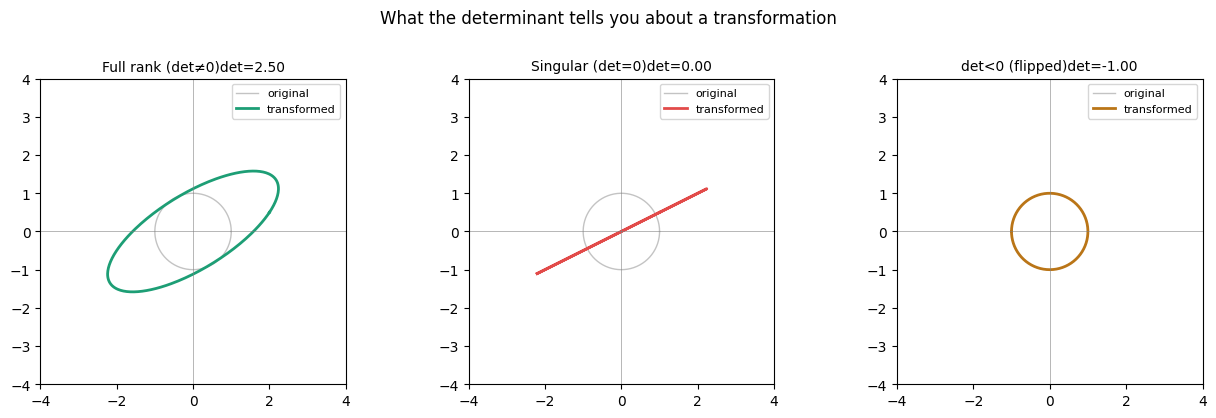

det(near_singular): 0.00010000000000021095
max value in inverse: 20001.0
max value with regularisation: 66.56
Push to GitHub: git add . && git commit -m 'Day 04: determinants' && git push


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Determinants ──────────────────────────────────────
A = np.array([[3., 1.],
              [2., 4.]])
B = np.array([[1., 2.],
              [1., 2.]])    # rank-deficient: row2 = row1

print("det(A):", np.linalg.det(A))        # 10.0
print("det(B):", np.linalg.det(B))        # ~0.0  → not invertible
print("det(A@A):", np.linalg.det(A@A))    # 100.0 = 10×10  ✓

# ── 2. Rank ──────────────────────────────────────────────
print("rank(A):", np.linalg.matrix_rank(A))   # 2 → full rank
print("rank(B):", np.linalg.matrix_rank(B))     # 1 → rank-deficient

C = np.array([[1.,2.,3.],
              [4.,5.,6.],
              [7.,8.,9.]])   # row3 = row1 + row2 (linearly dependent)
print("rank(C):", np.linalg.matrix_rank(C))     # 2, not 3!

# ── 3. Null space via SVD ────────────────────────────────
# SVD decomposes A = U @ diag(s) @ Vt
# Null space = rows of Vt where singular value ≈ 0
U, s, Vt = np.linalg.svd(C)
print("Singular values of C:", s.round(4))
# Last singular value ≈ 0 → rank=2 confirmed
# Null space basis vector:
null_vec = Vt[-1]  # last row of Vt
print("Null space vector:", null_vec.round(4))
print("C @ null_vec ≈ 0:", (C @ null_vec).round(8))  # should be ~zero

# ── 4. What det=0 looks like: visualise the collapse ─────
def show_transform(ax, M, title, col):
    pts = np.array([[np.cos(t), np.sin(t)]
                    for t in np.linspace(0, 2*np.pi, 300)]).T
    transformed = M @ pts
    ax.plot(pts[0], pts[1], color='#888', lw=1, alpha=0.5, label='original')
    ax.plot(transformed[0], transformed[1], color=col, lw=2, label='transformed')
    ax.set_xlim(-4,4); ax.set_ylim(-4,4)
    ax.set_aspect('equal')
    ax.axhline(0,color='gray',lw=0.4); ax.axvline(0,color='gray',lw=0.4)
    ax.set_title(f'{title}det={np.linalg.det(M):.2f}', fontsize=10)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(13,4))

# Full rank — circle stays a filled ellipse
M_full = np.array([[2., 1.],[0.5, 1.5]])
show_transform(axes[0], M_full, 'Full rank (det≠0)', '#1D9E75')

# det=0 — circle collapses to a line
M_singular = np.array([[1., 2.],[0.5, 1.]])
show_transform(axes[1], M_singular, 'Singular (det=0)', '#E24B4A')

# det<0 — circle flips orientation
M_flip = np.array([[-1., 0.],[0., 1.]])
show_transform(axes[2], M_flip, 'det<0 (flipped)', '#BA7517')

plt.suptitle('What the determinant tells you about a transformation', y=1.02)
plt.tight_layout()
plt.show()

# ── 5. Regularisation as a det fix ───────────────────────
near_singular = np.array([[1.0, 2.0],
                           [1.0, 2.0001]])  # nearly rank-deficient
print("det(near_singular):", np.linalg.det(near_singular))
# Try to invert — will have huge values
inv = np.linalg.inv(near_singular)
print("max value in inverse:", np.abs(inv).max().round(0))

# Add L2 regularisation (lambda * I)
lam = 0.01
reg = near_singular + lam * np.eye(2)
inv_reg = np.linalg.inv(reg)
print("max value with regularisation:", np.abs(inv_reg).max().round(2))
print("Push to GitHub: git add . && git commit -m 'Day 04: determinants' && git push")